In [2]:
# # 🎬 CineMatch – Intelligent Movie Recommendation System

# ## 📖 Project Overview

# CineMatch is a content-based movie recommendation system developed using Machine Learning and Natural Language Processing (NLP).

# The system recommends movies by analyzing similarities between movie content instead of relying on user ratings or viewing history.

# The recommendation engine considers multiple movie attributes including:

# - Overview
# - Genres
# - Keywords
# - Cast
# - Director

# Using these features, the system generates meaningful recommendations based on textual similarity.

# ---

# ## 🎯 Objectives

# - Analyze movie datasets using Exploratory Data Analysis (EDA)
# - Perform feature engineering on textual attributes
# - Apply Natural Language Processing techniques
# - Build a content-based recommendation engine
# - Recommend similar movies using Cosine Similarity
# - Deploy the model using Streamlit

# ---

# ## 📂 Dataset

# This project uses the TMDB 5000 Movie Dataset.

# Datasets used:

# - tmdb_5000_movies.csv
# - tmdb_5000_credits.csv

# ---

# ## 🛠 Technologies Used

# - Python
# - Pandas
# - NumPy
# - Matplotlib
# - Scikit-learn
# - Streamlit

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import pickle

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [6]:
# Load Dataset

movies = pd.read_csv("../data/tmdb_5000_movies.csv")
credits = pd.read_csv("../data/tmdb_5000_credits.csv")

print("Movies Shape :", movies.shape)
print("Credits Shape:", credits.shape)

Movies Shape : (4803, 20)
Credits Shape: (4803, 4)


In [7]:
# Merge Datasets
movies = movies.merge(credits, on="title")

print("Merged Dataset Shape:", movies.shape)

Merged Dataset Shape: (4809, 23)


In [9]:
# Data Overview

movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [10]:
movies.shape

(4809, 23)

In [11]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4809 non-null   int64  
 1   genres                4809 non-null   object 
 2   homepage              1713 non-null   object 
 3   id                    4809 non-null   int64  
 4   keywords              4809 non-null   object 
 5   original_language     4809 non-null   object 
 6   original_title        4809 non-null   object 
 7   overview              4806 non-null   object 
 8   popularity            4809 non-null   float64
 9   production_companies  4809 non-null   object 
 10  production_countries  4809 non-null   object 
 11  release_date          4808 non-null   object 
 12  revenue               4809 non-null   int64  
 13  runtime               4807 non-null   float64
 14  spoken_languages      4809 non-null   object 
 15  status               

In [12]:
movies.describe(include="all")

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
count,4.809000e+03,4809,1713,4809.000000,4809,4809,4809,4806,4809.000000,4809,4809,4808,4.809000e+03,4807.000000,4809,4809,3965,4809,4809.000000,4809.000000,4809.000000,4809,4809
unique,NaN,1175,1691,NaN,4222,37,4801,4800,NaN,3697,469,3280,NaN,NaN,544,3,3944,4800,NaN,NaN,NaN,4761,4776
top,NaN,"[{""id"": 18, ""name"": ""Drama""}]",http://www.missionimpossible.com/,NaN,[],en,Batman,The Dynamic Duo faces four super-villains who ...,NaN,[],"[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2006-01-01,NaN,NaN,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Based on a true story.,The Host,NaN,NaN,NaN,[],[]
freq,NaN,372,4,NaN,412,4510,4,2,NaN,352,2979,10,NaN,NaN,3175,4801,3,4,NaN,NaN,NaN,43,28
mean,2.902780e+07,NaN,NaN,57120.571429,NaN,NaN,NaN,NaN,21.491664,NaN,NaN,NaN,8.227511e+07,106.882255,NaN,NaN,NaN,NaN,6.092514,690.331670,57120.571429,NaN,NaN
std,4.070473e+07,NaN,NaN,88653.369849,NaN,NaN,NaN,NaN,31.803366,NaN,NaN,NaN,1.628379e+08,22.602535,NaN,NaN,NaN,NaN,1.193989,1234.187111,88653.369849,NaN,NaN
min,0.000000e+00,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.000000e+00,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,5.000000,NaN,NaN
25%,7.800000e+05,NaN,NaN,9012.000000,NaN,NaN,NaN,NaN,4.667230,NaN,NaN,NaN,0.000000e+00,94.000000,NaN,NaN,NaN,NaN,5.600000,54.000000,9012.000000,NaN,NaN
50%,1.500000e+07,NaN,NaN,14624.000000,NaN,NaN,NaN,NaN,12.921594,NaN,NaN,NaN,1.917000e+07,103.000000,NaN,NaN,NaN,NaN,6.200000,235.000000,14624.000000,NaN,NaN
75%,4.000000e+07,NaN,NaN,58595.000000,NaN,NaN,NaN,NaN,28.350529,NaN,NaN,NaN,9.291317e+07,118.000000,NaN,NaN,NaN,NaN,6.800000,737.000000,58595.000000,NaN,NaN


In [13]:
movies.isnull().sum()

budget                     0
genres                     0
homepage                3096
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
movie_id                   0
cast                       0
crew                       0
dtype: int64

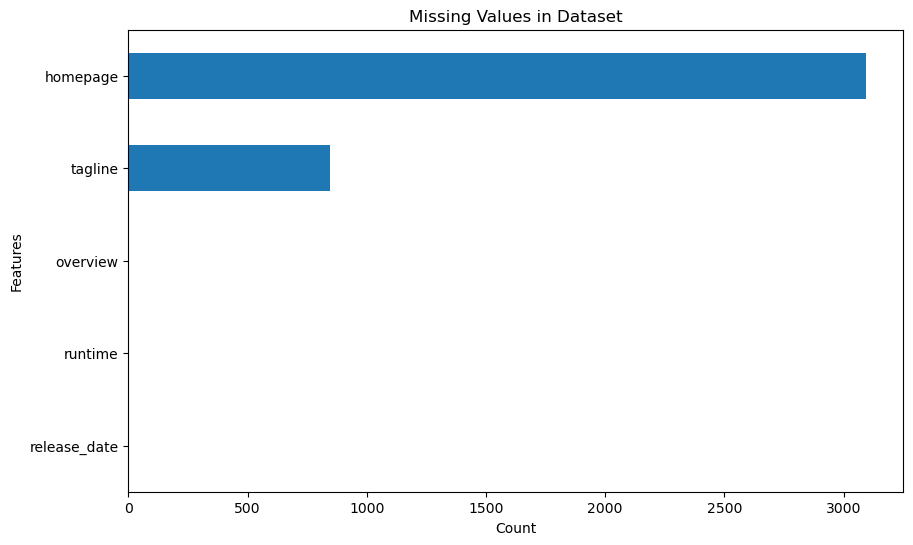

In [14]:
# Exploratory Data Analysis (EDA)


# Missing Values

missing = movies.isnull().sum()
missing = missing[missing > 0].sort_values()

plt.figure(figsize=(10,6))
missing.plot(kind='barh')

plt.title("Missing Values in Dataset")
plt.xlabel("Count")
plt.ylabel("Features")

plt.show()

In [16]:
# ### Observation

# - The **homepage** column contains the highest number of missing values.
# - Only a few records have missing values in **overview** and **runtime**.
# - Since recommendation primarily depends on textual content, only relevant missing values will be handled later.

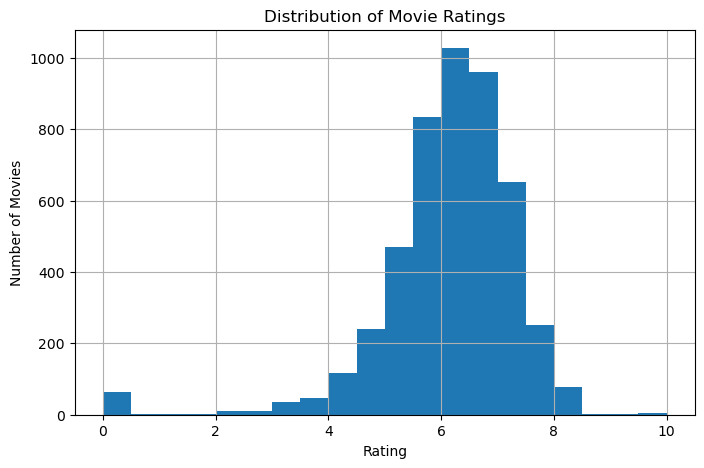

In [17]:
# Movie Rating Distribution 


plt.figure(figsize=(8,5))

movies['vote_average'].hist(bins=20)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")

plt.show()

In [18]:
# ### Observation

# - Most movies have ratings between **5 and 7**.
# - Very few movies achieve ratings above **8.5**, indicating that highly rated movies are relatively rare.

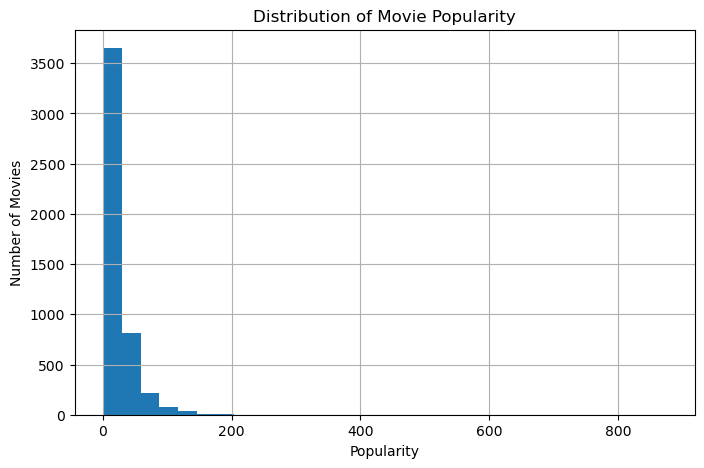

In [20]:
# Popularity Distribution
plt.figure(figsize=(8,5))

movies['popularity'].hist(bins=30)

plt.title("Distribution of Movie Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Movies")

plt.show()

In [21]:
# ### Observation

# - The popularity distribution is highly skewed.
# - Most movies have relatively low popularity scores, while only a small number are extremely popular.

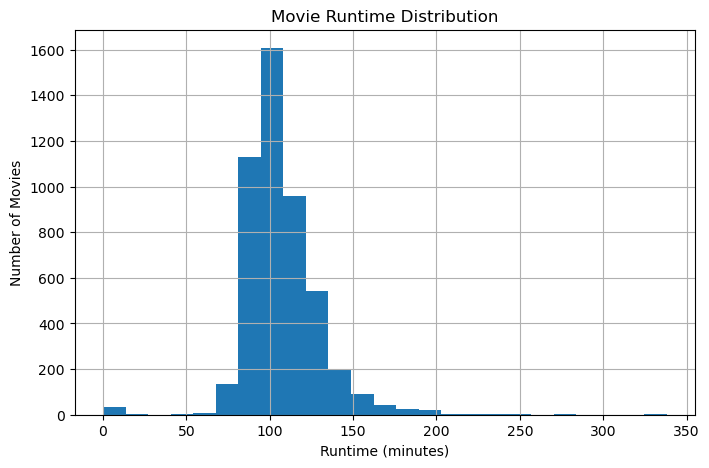

In [22]:
# Runtime Distribution

plt.figure(figsize=(8,5))

movies['runtime'].dropna().hist(bins=25)

plt.title("Movie Runtime Distribution")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Number of Movies")

plt.show()

In [23]:
# ## Observation

# - Most movies have a runtime between **90 and 120 minutes**.
# - Extremely long movies are uncommon.

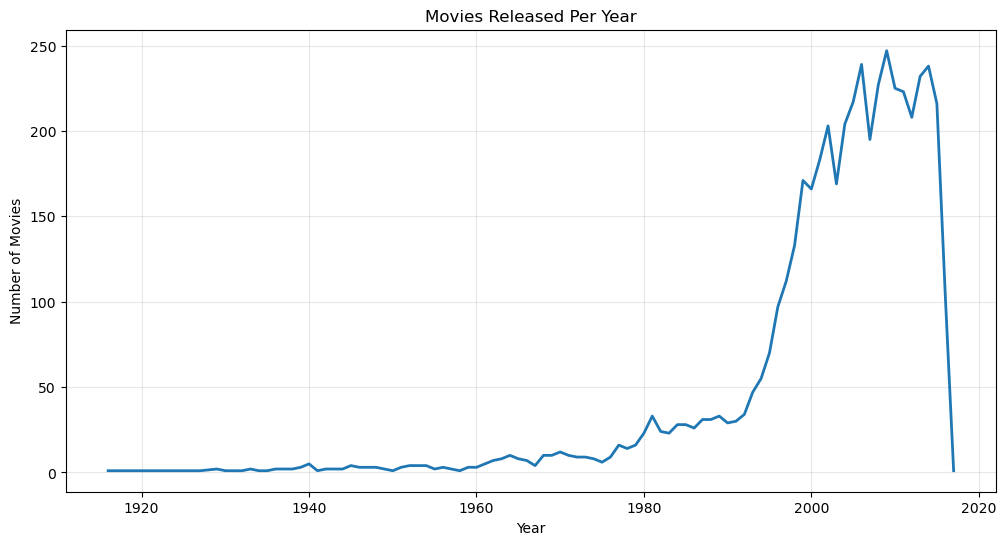

In [24]:
# Movies Released Per Year

# Convert release_date to datetime
movies['release_date'] = pd.to_datetime(
    movies['release_date'],
    errors='coerce'
)

movies['release_year'] = movies['release_date'].dt.year

release_trend = movies['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,6))

plt.plot(release_trend.index,
         release_trend.values,
         linewidth=2)

plt.title("Movies Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")

plt.grid(alpha=0.3)

plt.show()

In [26]:
# ### Observation

# - Movie production has increased significantly over the years.
# - The highest number of movies in the dataset were released after the year 2000.
# - Older movies are comparatively fewer, indicating that the dataset is biased toward modern cinema.

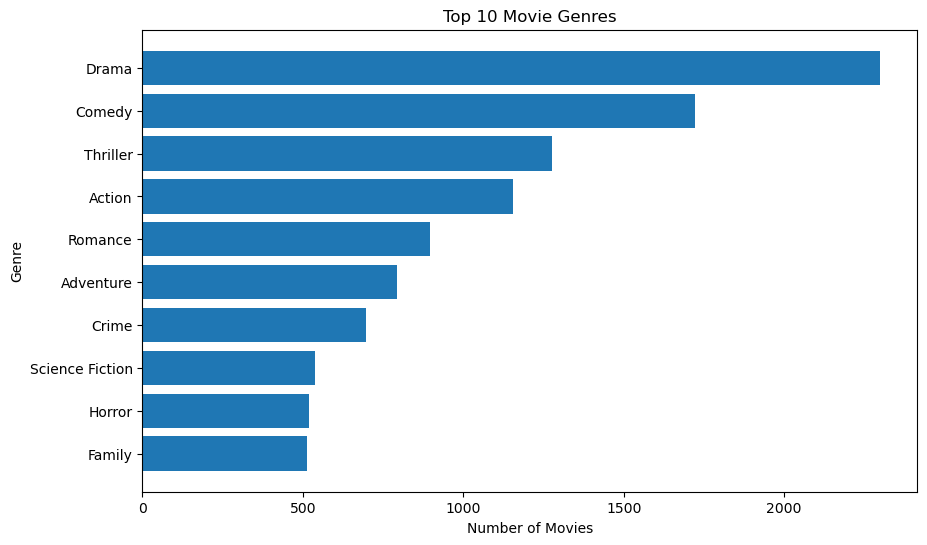

In [28]:
# Top 10 Genre
import ast

# Function to extract genre names
def extract_genres(text):
    genres = []
    for item in ast.literal_eval(text):
        genres.append(item['name'])
    return genres

# Apply function
movies['genre_list'] = movies['genres'].apply(extract_genres)

# Count genres
from collections import Counter

genre_counter = Counter()

for genres in movies['genre_list']:
    genre_counter.update(genres)

genre_df = pd.DataFrame(
    genre_counter.items(),
    columns=['Genre', 'Count']
).sort_values(
    by='Count',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    genre_df['Genre'],
    genre_df['Count']
)

plt.title("Top 10 Movie Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")

plt.gca().invert_yaxis()

plt.show()

In [29]:
# ### Observation

# - Drama is the most common genre in the dataset.
# - Comedy and Thriller are also highly represented.
# - Genres like Western and War appear much less frequently.

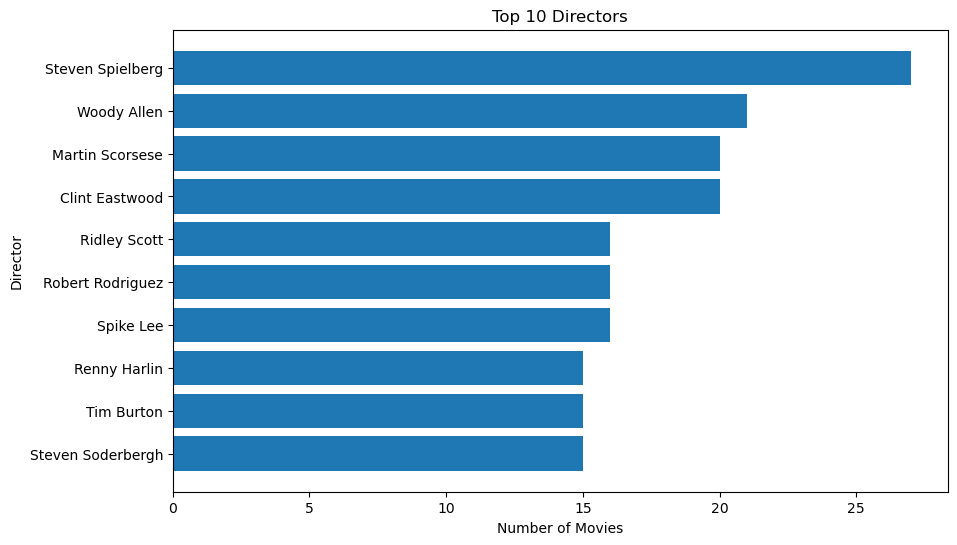

In [31]:
# Top 10 Directors

# Function to extract director
def get_director(text):
    for item in ast.literal_eval(text):
        if item['job'] == 'Director':
            return item['name']
    return np.nan

movies['director'] = movies['crew'].apply(get_director)

director_df = (
    movies['director']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    director_df.index,
    director_df.values
)

plt.title("Top 10 Directors")
plt.xlabel("Number of Movies")
plt.ylabel("Director")

plt.gca().invert_yaxis()

plt.show()

In [32]:
# ### Observation

# - Steven Spielberg appears among the most frequent directors.
# - Several well-known Hollywood directors have multiple films in the dataset.
# - The distribution highlights directors with long and influential careers.

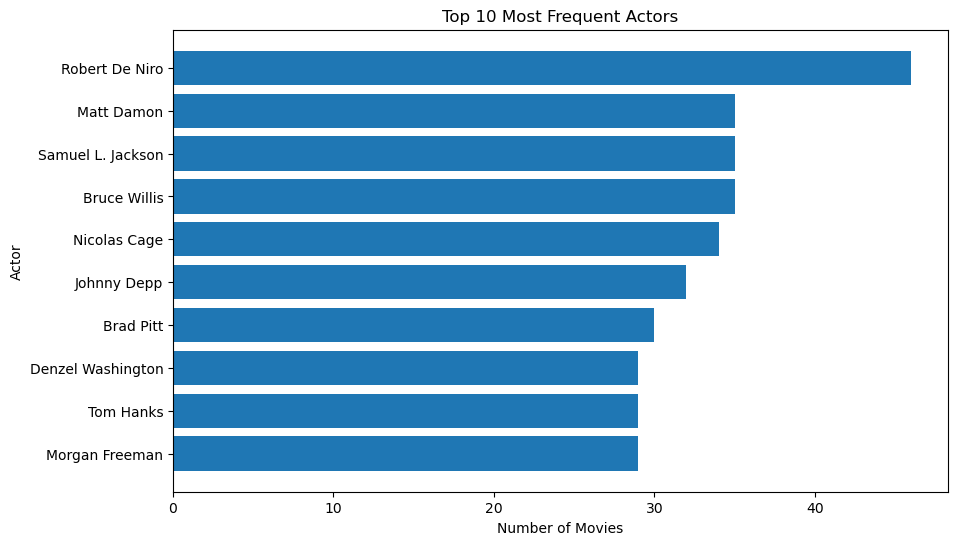

In [34]:
# Top 10 Actors

# Function to extract top 3 actors
def extract_cast(text):
    actors = []
    for actor in ast.literal_eval(text)[:3]:
        actors.append(actor['name'])
    return actors

# Create cast list
movies['cast_list'] = movies['cast'].apply(extract_cast)

# Count actor frequency
from collections import Counter

actor_counter = Counter()

for actors in movies['cast_list']:
    actor_counter.update(actors)

actor_df = pd.DataFrame(
    actor_counter.items(),
    columns=['Actor', 'Count']
)

actor_df = actor_df.sort_values(
    by='Count',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    actor_df['Actor'],
    actor_df['Count']
)

plt.title("Top 10 Most Frequent Actors")
plt.xlabel("Number of Movies")
plt.ylabel("Actor")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
# ### Observation

# - A few actors appear in a large number of movies.
# - Popular actors often work across multiple genres.
# - Their recurring presence makes cast information valuable for recommendations.

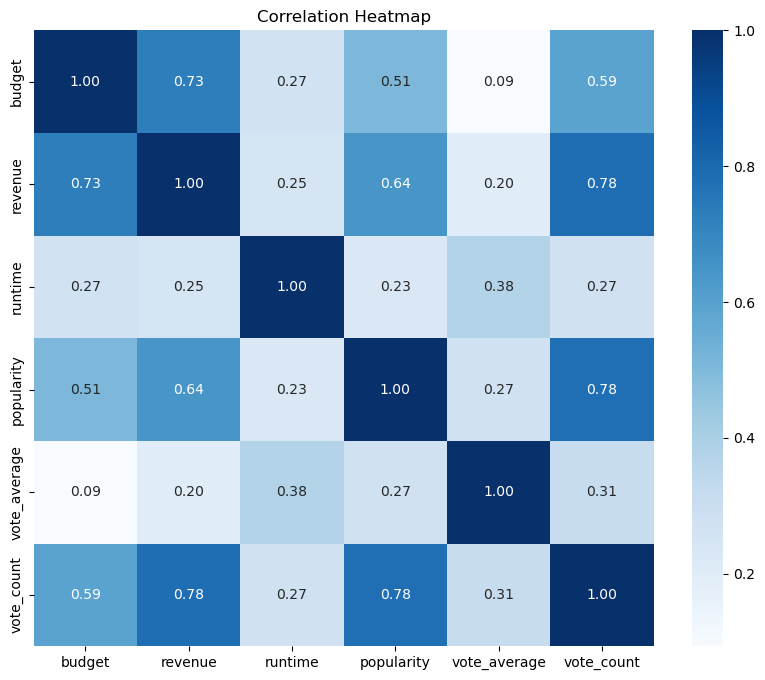

In [35]:
# Correlation Heatmap

correlation = movies[
    [
        'budget',
        'revenue',
        'runtime',
        'popularity',
        'vote_average',
        'vote_count'
    ]
].corr()

plt.figure(figsize=(10,8))

import seaborn as sns

sns.heatmap(
    correlation,
    annot=True,
    cmap='Blues',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [36]:
# ### Observation

# - Revenue shows a positive correlation with budget.
# - Vote count is positively correlated with popularity.
# - Vote average has only a weak correlation with other numerical features.

In [37]:
# # Feature Engineering

# ## Objective

# The original dataset contains many features that are not useful for content-based recommendations.

# In this section, we retain only the columns that contribute to understanding a movie's content and remove unnecessary information.

In [43]:
# Keep only the features required for recommendation
movies = movies[
    [
        'movie_id',
        'title',
        'overview',
        'genres',
        'keywords',
        'cast',
        'crew'
    ]
]

movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, Science Fiction]","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [39]:
# Check Missing Values Again

movies.isnull().sum()

movie_id    0
title       0
overview    3
genres      0
keywords    0
cast        0
crew        0
dtype: int64

In [40]:
# Remove Missing Values

movies.dropna(inplace=True)

print("Dataset Shape:", movies.shape)

Dataset Shape: (4806, 7)


In [53]:
# # Extract Genre

import ast

def extract_feature_names(text):
    if isinstance(text, list):
        return text
    return [item['name'] for item in ast.literal_eval(text)]

In [60]:
# Extract Cast

def extract_top_cast(text):
    if isinstance(text, list):
        return text[:3]

    return [actor['name'] for actor in ast.literal_eval(text)[:3]]

movies['cast'] = movies['cast'].apply(extract_cast)

movies[['title', 'cast']].head()

,title,cast
0,Avatar,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]"
1,Pirates of the Caribbean: At World's End,"[Johnny Depp, Orlando Bloom, Keira Knightley]"
2,Spectre,"[Daniel Craig, Christoph Waltz, Léa Seydoux]"
3,The Dark Knight Rises,"[Christian Bale, Michael Caine, Gary Oldman]"
4,John Carter,"[Taylor Kitsch, Lynn Collins, Samantha Morton]"


In [58]:
# Extract Director

def extract_director(text):

    if isinstance(text, list):
        return text

    for member in ast.literal_eval(text):
        if member['job'] == 'Director':
            return [member['name']]

    return []

movies['director'] = movies['crew'].apply(extract_director)

movies[['title', 'director']].head()

,title,director
0,Avatar,[James Cameron]
1,Pirates of the Caribbean: At World's End,[Gore Verbinski]
2,Spectre,[Sam Mendes]
3,The Dark Knight Rises,[Christopher Nolan]
4,John Carter,[Andrew Stanton]


In [61]:

# Remove spaces from multi-word values

movies['genres'] = movies['genres'].apply(
    lambda x: [i.replace(" ", "") for i in x]
)

movies['keywords'] = movies['keywords'].apply(
    lambda x: [i.replace(" ", "") for i in x]
)

movies['cast'] = movies['cast'].apply(
    lambda x: [i.replace(" ", "") for i in x]
)

movies['director'] = movies['director'].apply(
    lambda x: [i.replace(" ", "") for i in x]
)

movies[['genres', 'cast', 'director']].head()

,genres,cast,director
0,"[Action, Adventure, Fantasy, ScienceFiction]","[SamWorthington, ZoeSaldana, SigourneyWeaver]",[JamesCameron]
1,"[Adventure, Fantasy, Action]","[JohnnyDepp, OrlandoBloom, KeiraKnightley]",[GoreVerbinski]
2,"[Action, Adventure, Crime]","[DanielCraig, ChristophWaltz, LéaSeydoux]",[SamMendes]
3,"[Action, Crime, Drama, Thriller]","[ChristianBale, MichaelCaine, GaryOldman]",[ChristopherNolan]
4,"[Action, Adventure, ScienceFiction]","[TaylorKitsch, LynnCollins, SamanthaMorton]",[AndrewStanton]


In [62]:
movies.iloc[0]

movie_id                                                19995
title                                                  Avatar
overview    In the 22nd century, a paraplegic Marine is di...
genres           [Action, Adventure, Fantasy, ScienceFiction]
keywords    [cultureclash, future, spacewar, spacecolony, ...
cast            [SamWorthington, ZoeSaldana, SigourneyWeaver]
crew        [{"credit_id": "52fe48009251416c750aca23", "de...
director                                       [JamesCameron]
Name: 0, dtype: object

In [63]:
# Convert overview from string to list of words
movies['overview'] = movies['overview'].apply(lambda x: x.split())

movies[['title', 'overview']].head()

,title,overview
0,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin..."
1,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d..."
2,Spectre,"[A, cryptic, message, from, Bond’s, past, send..."
3,The Dark Knight Rises,"[Following, the, death, of, District, Attorney..."
4,John Carter,"[John, Carter, is, a, war-weary,, former, mili..."


In [64]:
movies['features'] = (
    movies['overview']
    + movies['genres']
    + movies['keywords']
    + movies['cast']
    + movies['director']
)

movies[['title', 'features']].head()

,title,features
0,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin..."
1,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d..."
2,Spectre,"[A, cryptic, message, from, Bond’s, past, send..."
3,The Dark Knight Rises,"[Following, the, death, of, District, Attorney..."
4,John Carter,"[John, Carter, is, a, war-weary,, former, mili..."


In [65]:
# Convert it into a String


movies['features'] = movies['features'].apply(
    lambda x: " ".join(x).lower()
)

movies[['title', 'features']].head()

,title,features
0,Avatar,"in the 22nd century, a paraplegic marine is di..."
1,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha..."
2,Spectre,a cryptic message from bond’s past sends him o...
3,The Dark Knight Rises,following the death of district attorney harve...
4,John Carter,"john carter is a war-weary, former military ca..."


In [66]:
# Create the Final Dataset

final_df = movies[['movie_id', 'title', 'features']]

final_df.head()

,movie_id,title,features
0,19995,Avatar,"in the 22nd century, a paraplegic marine is di..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha..."
2,206647,Spectre,a cryptic message from bond’s past sends him o...
3,49026,The Dark Knight Rises,following the death of district attorney harve...
4,49529,John Carter,"john carter is a war-weary, former military ca..."


In [68]:
# Import PorterStemmer

from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

In [69]:
# Create a Stemming Function

def stem_text(text):
    words = text.split()
    stemmed_words = [ps.stem(word) for word in words]
    return " ".join(stemmed_words)

In [72]:
# Apply Stemming


final_df['processed_features'] = final_df['features'].apply(stem_text)

In [74]:
final_df.iloc[0]['processed_features']

'in the 22nd century, a parapleg marin is dispatch to the moon pandora on a uniqu mission, but becom torn between follow order and protect an alien civilization. action adventur fantasi sciencefict cultureclash futur spacewar spacecoloni societi spacetravel futurist romanc space alien tribe alienplanet cgi marin soldier battl loveaffair antiwar powerrel mindandsoul 3d samworthington zoesaldana sigourneyweav jamescameron'

In [75]:
# Vectorization

from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(
    max_features=5000,
    stop_words='english'
)

vectors = cv.fit_transform(final_df['processed_features']).toarray()

In [77]:
cv.get_feature_names_out()[:20]

array(['000', '007', '10', '100', '11', '12', '13', '14', '15', '16',
       '17', '17th', '18', '18th', '18thcenturi', '19', '1910', '1920',
       '1930', '1940'], dtype=object)

In [78]:
# Cosine Similarity

# Now we'll calculate how similar every movie is to every other movie.

from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(vectors)

In [80]:
similarity[0]

array([1.        , 0.08458258, 0.08718573, ..., 0.04559608, 0.        ,
       0.        ], shape=(4806,))

In [81]:
# Recommendation Function

def recommend(movie_name):
    
    # Check if movie exists
    if movie_name not in final_df['title'].values:
        return "Movie not found!"
    
    # Get movie index
    movie_index = final_df[final_df['title'] == movie_name].index[0]
    
    # Get similarity scores
    distances = similarity[movie_index]
    
    # Sort movies by similarity
    movie_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )[1:6]
    
    # Display recommendations
    recommendations = []

    for movie in movie_list:
        recommendations.append(final_df.iloc[movie[0]].title)

    return recommendations

In [87]:
# Model Evaluation

recommend("Avatar")

['Aliens vs Predator: Requiem',
 'Falcon Rising',
 'Independence Day',
 'Titan A.E.',
 'Aliens']

In [88]:
recommend("The Dark Knight")

['The Dark Knight Rises',
 'Batman Begins',
 'Batman Returns',
 'Batman Forever',
 'Batman']

In [90]:
recommend("Iron Man")

['Iron Man 3',
 'Iron Man 2',
 'Avengers: Age of Ultron',
 'The Avengers',
 'Captain America: Civil War']

In [91]:
recommend("Toy Story")

['Toy Story 2',
 'Toy Story 3',
 'The Adventures of Elmo in Grouchland',
 "Should've Been Romeo",
 "Harry Potter and the Philosopher's Stone"]

In [92]:
recommend("The Avengers")

['Iron Man 3',
 'Avengers: Age of Ultron',
 'Captain America: Civil War',
 'Captain America: The First Avenger',
 'Iron Man']

In [ ]:
# ## Model Evaluation

# The recommendation engine was tested on multiple movies from different genres.

# The generated recommendations were found to be contextually relevant, indicating that the content-based approach successfully captures similarities using movie metadata.

# Although no numerical evaluation metric is available due to the absence of user preference data, qualitative testing demonstrates that the system produces meaningful recommendations.

In [97]:
# Saving the model

import pickle

pickle.dump(final_df, open("movies.pkl", "wb"))
pickle.dump(similarity, open("similarity.pkl", "wb"))

In [100]:

# # Conclusion

# A content-based movie recommendation system was developed using Natural Language Processing and Machine Learning techniques.

# The recommendation engine combines information from movie overviews, genres, keywords, cast members, and directors to identify similar movies using CountVectorizer and Cosine Similarity.

# The project demonstrates the complete machine learning workflow, including data preprocessing, exploratory data analysis, feature engineering, text vectorization, similarity computation, and deployment readiness.

In [101]:
# # Future Scope

# - Hybrid recommendation system combining content-based and collaborative filtering.
# - Integration with TMDB API for live movie information and posters.
# - Personalized recommendations using user watch history.
# - Advanced text embeddings using Sentence Transformers or BERT.
# - Deployment on Streamlit Cloud for public access.
    

In [106]:
# # Project Summary

# **Problem Statement**
# Develop a content-based movie recommendation system using movie metadata.

# **Dataset**
# TMDB 5000 Movies Dataset (~4,800 movies)

# **Machine Learning Technique**
# - CountVectorizer
# - Cosine Similarity

# **NLP Techniques**
# - Tokenization
# - Stop Word Removal
# - Porter Stemming

# **Features Used**
# - Overview
# - Genres
# - Keywords
# - Cast
# - Director

# **Outcome**
# Successfully generated relevant movie recommendations based on content similarity.